# 🛒 Superstore Sales Analysis & Forecasting
**Author:** Alessandra Gonçalves  
**Dataset:** Sample - Superstore (Tableau Public)  
**Goal:** End-to-end analysis covering EDA, profit insights, and ML-based sales forecasting.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Profit Analysis by Category & Region](#3)
4. [Sales Forecasting with Machine Learning](#4)
5. [Conclusions](#5)

## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\aless\OneDrive\Área de Trabalho\superstore-analysis
['data', 'plots', 'superstore_analysis.ipynb']


In [5]:
# Load dataset
# Download from: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
df = pd.read_csv('data/Sample - Superstore.csv', encoding='latin1')
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print(f' Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

 Dataset loaded: 9,994 rows × 25 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Days to Ship
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,7


In [6]:
# Quick overview
print('=== DATASET INFO ===')
print(f'Period: {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Total Sales: ${df["Sales"].sum():,.0f}')
print(f'Total Profit: ${df["Profit"].sum():,.0f}')
print(f'Profit Margin: {df["Profit"].sum()/df["Sales"].sum()*100:.1f}%')
print(f'Unique Customers: {df["Customer ID"].nunique():,}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

=== DATASET INFO ===
Period: 2014-01-03 → 2017-12-30
Total Sales: $2,297,201
Total Profit: $286,397
Profit Margin: 12.5%
Unique Customers: 793

Missing values:
Series([], dtype: int64)


## 2. Exploratory Data Analysis (EDA) <a id='2'></a>

In [7]:
import os
os.makedirs('plots', exist_ok=True)
print(' plots folder ready:', os.getcwd())

 plots folder ready: c:\Users\aless\OneDrive\Área de Trabalho\superstore-analysis


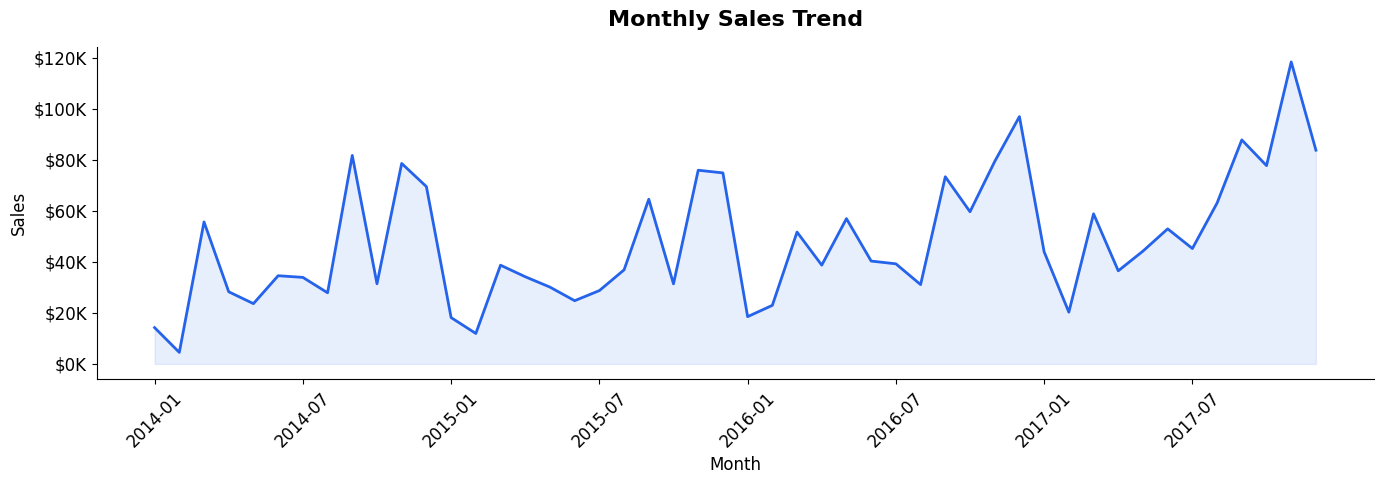

In [8]:
# Monthly sales trend
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly['Order Date'] = monthly['Order Date'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Order Date'], monthly['Sales'], color='#2563eb', linewidth=2)
ax.fill_between(range(len(monthly)), monthly['Sales'], alpha=0.1, color='#2563eb')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels(monthly['Order Date'][::6], rotation=45)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.savefig('plots/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

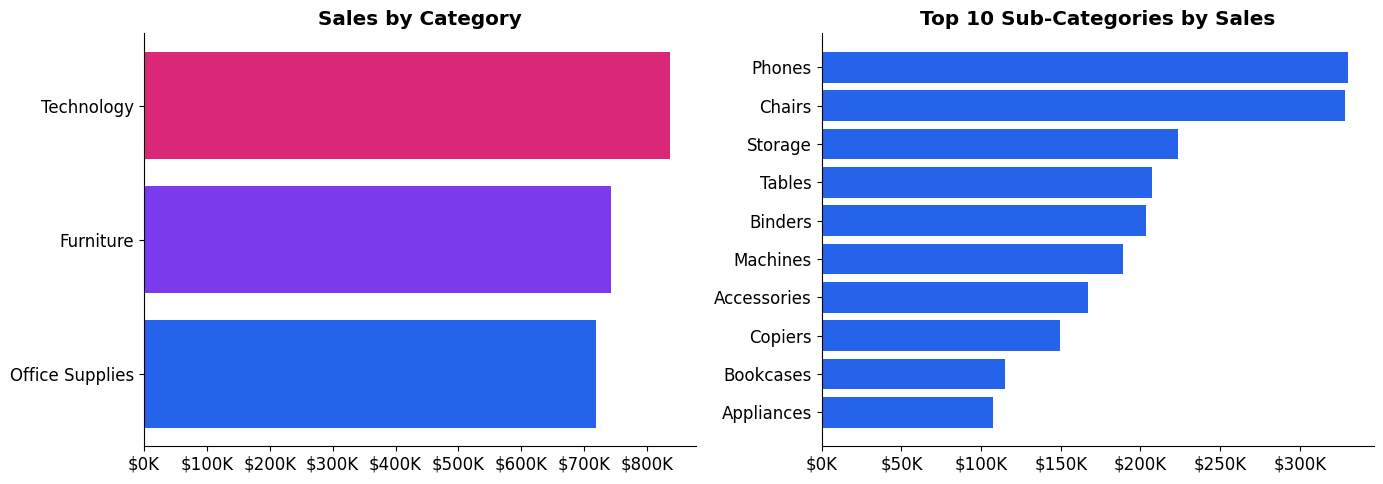

In [26]:
# Sales by category and sub-category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values, color=['#2563eb','#7c3aed','#db2777'])
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title('Sales by Category', fontweight='bold')

# By sub-category
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)
axes[1].barh(sub_sales.index, sub_sales.values, color='#2563eb')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_title('Top 10 Sub-Categories by Sales', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

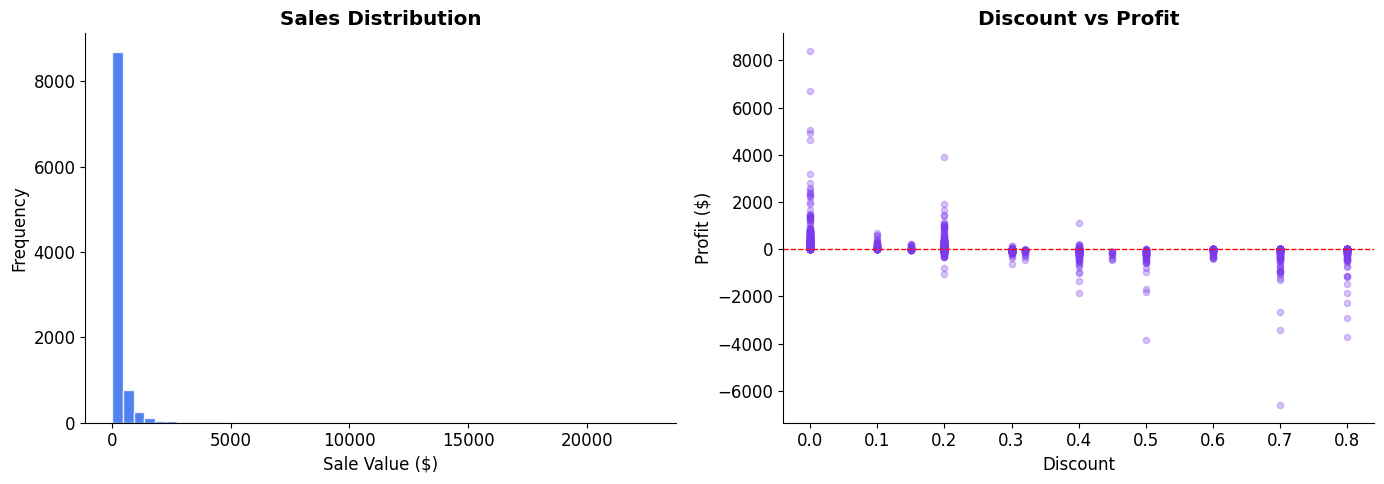

In [27]:
# Sales distribution & discount impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales distribution
axes[0].hist(df['Sales'], bins=50, color='#2563eb', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Sale Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sales Distribution', fontweight='bold')

# Discount vs Profit
axes[1].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#7c3aed', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Profit ($)')
axes[1].set_title('Discount vs Profit', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Profit Analysis by Category & Region <a id='3'></a>

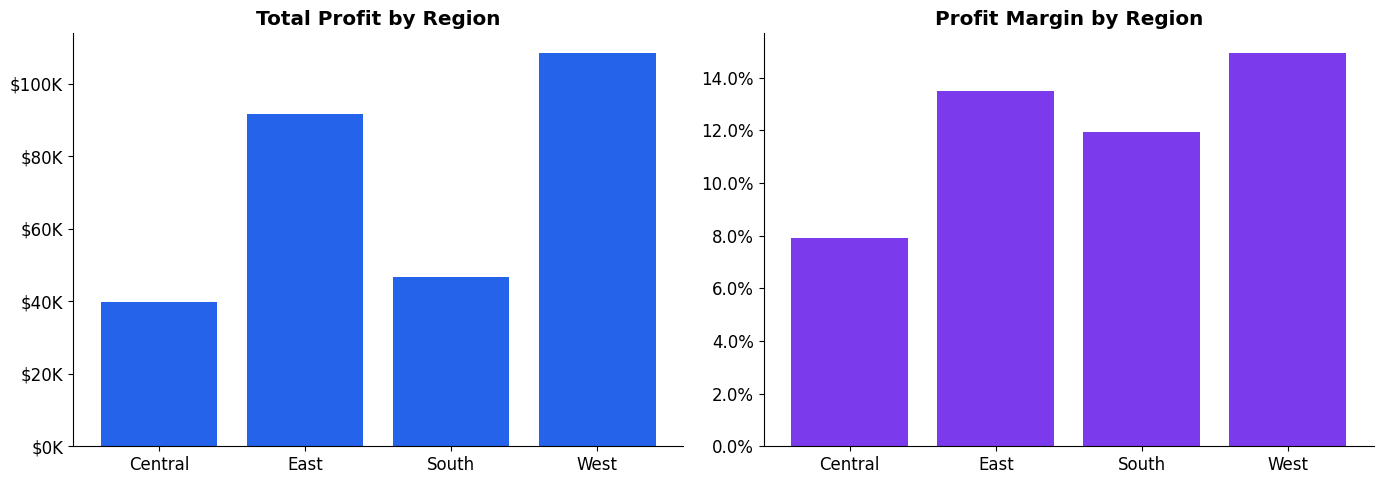

 Region       Sales      Profit  Orders    Margin
Central 501239.8908  39706.3625    1175  7.921629
   East 678781.2400  91522.7800    1401 13.483399
  South 391721.9050  46749.4303     822 11.934342
   West 725457.8245 108418.4489    1611 14.944831


In [28]:
# Profit by region
region_metrics = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
region_metrics['Margin'] = region_metrics['Profit'] / region_metrics['Sales'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2563eb' if p > 0 else '#dc2626' for p in region_metrics['Profit']]
axes[0].bar(region_metrics['Region'], region_metrics['Profit'], color=colors)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title('Total Profit by Region', fontweight='bold')

axes[1].bar(region_metrics['Region'], region_metrics['Margin'], color='#7c3aed')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))
axes[1].set_title('Profit Margin by Region', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/profit_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(region_metrics.to_string(index=False))

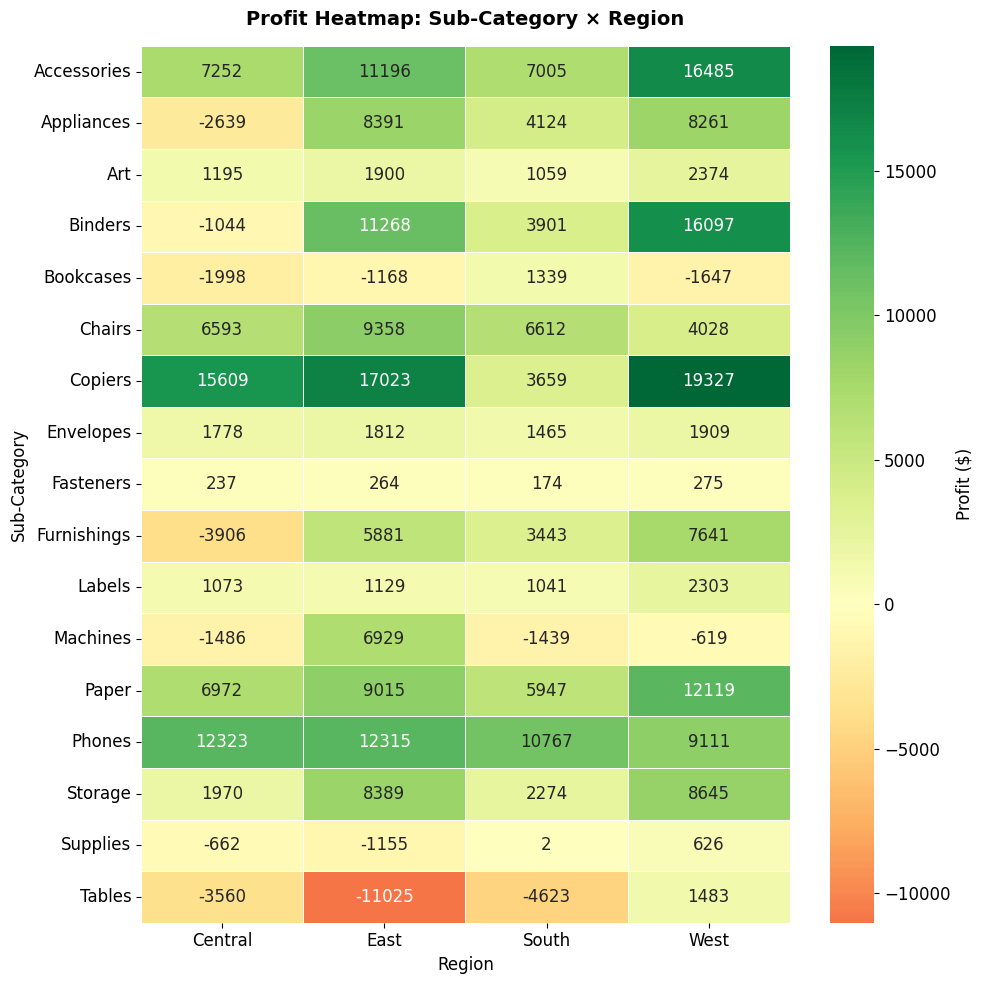

In [29]:
# Profit heatmap: Category x Region
pivot = df.pivot_table(values='Profit', index='Sub-Category', columns='Region', aggfunc='sum')

plt.figure(figsize=(10, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Profit ($)'})
plt.title('Profit Heatmap: Sub-Category × Region', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/profit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

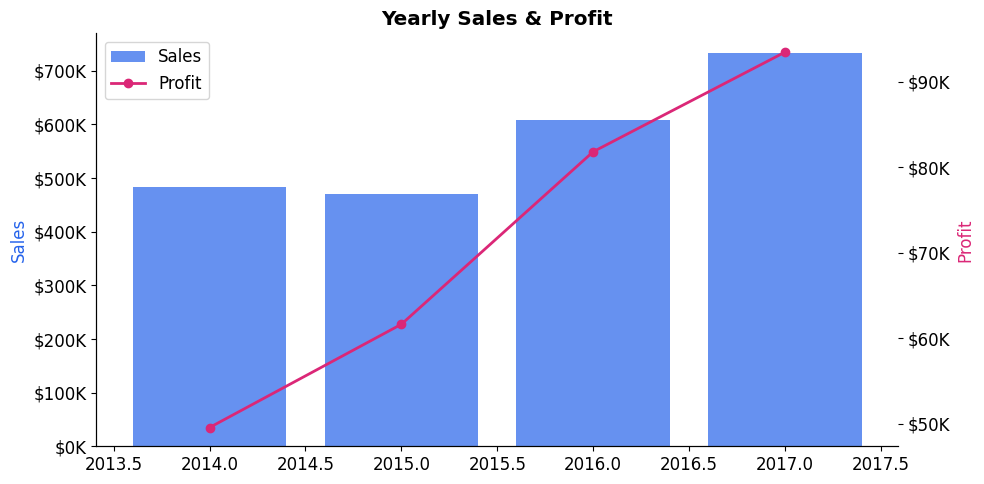

In [30]:
# Yearly growth
yearly = df.groupby('Year').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
yearly['Sales_Growth'] = yearly['Sales'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(yearly['Year'], yearly['Sales'], color='#2563eb', alpha=0.7, label='Sales')
ax2.plot(yearly['Year'], yearly['Profit'], color='#db2777', marker='o', linewidth=2, label='Profit')

ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.set_ylabel('Sales', color='#2563eb')
ax2.set_ylabel('Profit', color='#db2777')
ax1.set_title('Yearly Sales & Profit', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('plots/yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sales Forecasting with Machine Learning <a id='4'></a>

We'll predict **order-level sales** using features like category, region, discount, quantity, and time-based features.

In [31]:
# Feature engineering for ML
ml_df = df.copy()

# Encode categoricals
le = LabelEncoder()
for col in ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']:
    ml_df[col + '_enc'] = le.fit_transform(ml_df[col])

features = ['Category_enc', 'Sub-Category_enc', 'Region_enc', 'Segment_enc',
            'Ship Mode_enc', 'Quantity', 'Discount', 'Year', 'Month',
            'Quarter', 'Days to Ship']

X = ml_df[features]
y = ml_df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples')

Train: 7,995 samples | Test: 1,999 samples


In [32]:
# Train & evaluate models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred),
        'predictions': y_pred
    }
    print(f'{name:25s} → RMSE: ${results[name]["RMSE"]:,.0f} | MAE: ${results[name]["MAE"]:,.0f} | R²: {results[name]["R²"]:.4f}')

Linear Regression         → RMSE: $752 | MAE: $273 | R²: 0.0437
Random Forest             → RMSE: $692 | MAE: $220 | R²: 0.1898
Gradient Boosting         → RMSE: $690 | MAE: $204 | R²: 0.1933


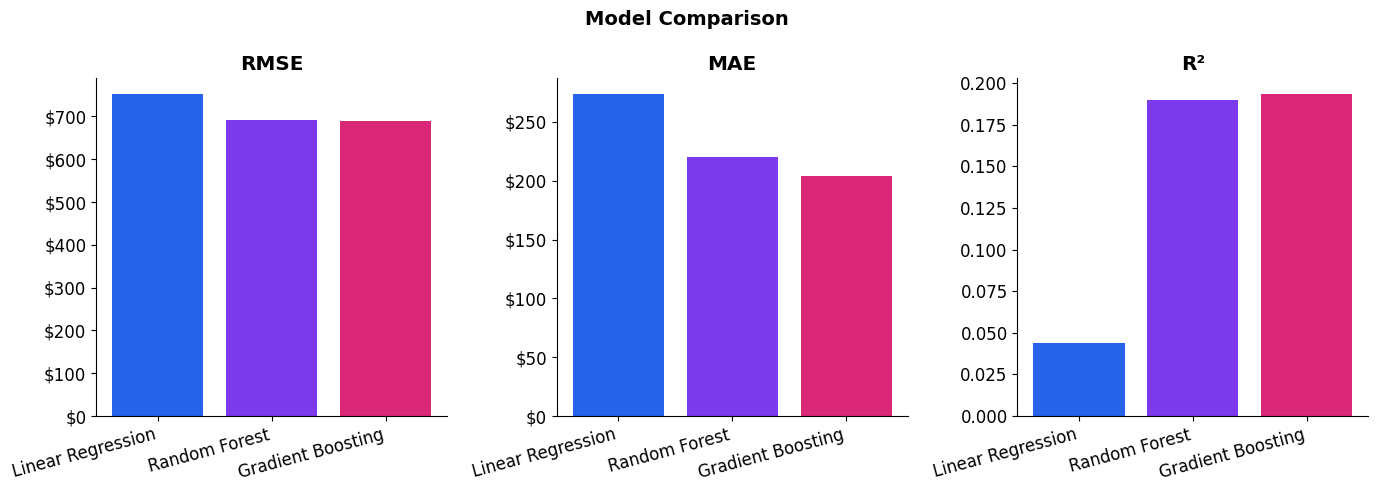

In [33]:
# Model comparison chart
metrics_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R²']]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#2563eb', '#7c3aed', '#db2777']

for i, metric in enumerate(['RMSE', 'MAE', 'R²']):
    axes[i].bar(metrics_df.index, metrics_df[metric], color=colors)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticklabels(metrics_df.index, rotation=15, ha='right')
    if metric != 'R²':
        axes[i].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

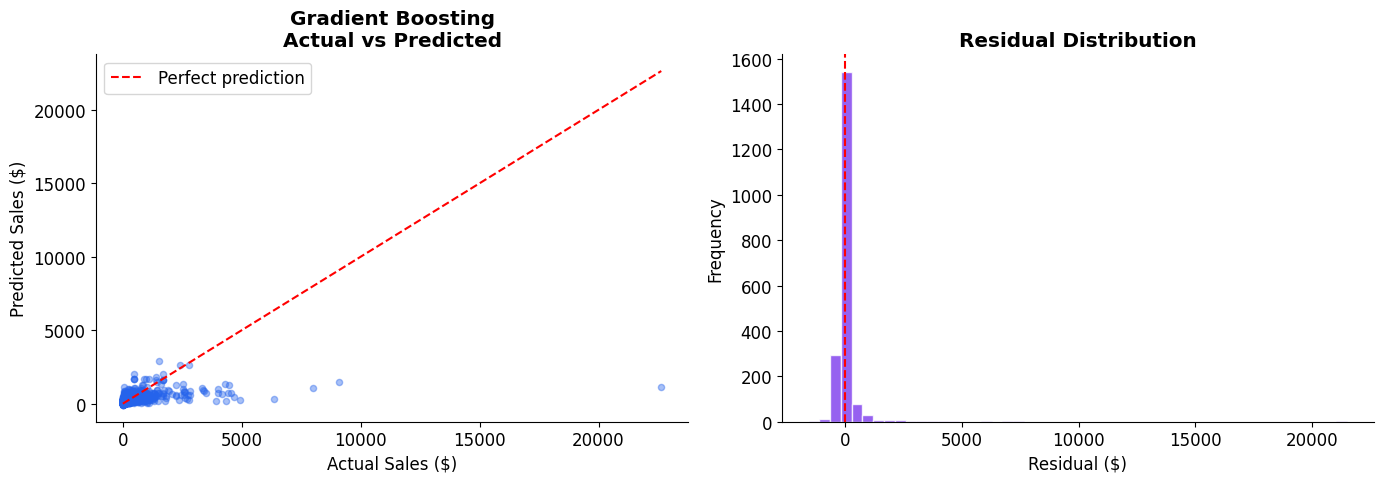

In [34]:
# Best model: Actual vs Predicted
best_model = max(results, key=lambda x: results[x]['R²'])
y_pred_best = results[best_model]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='#2563eb', s=20)
lims = [0, max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title(f'{best_model}\nActual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=50, color='#7c3aed', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

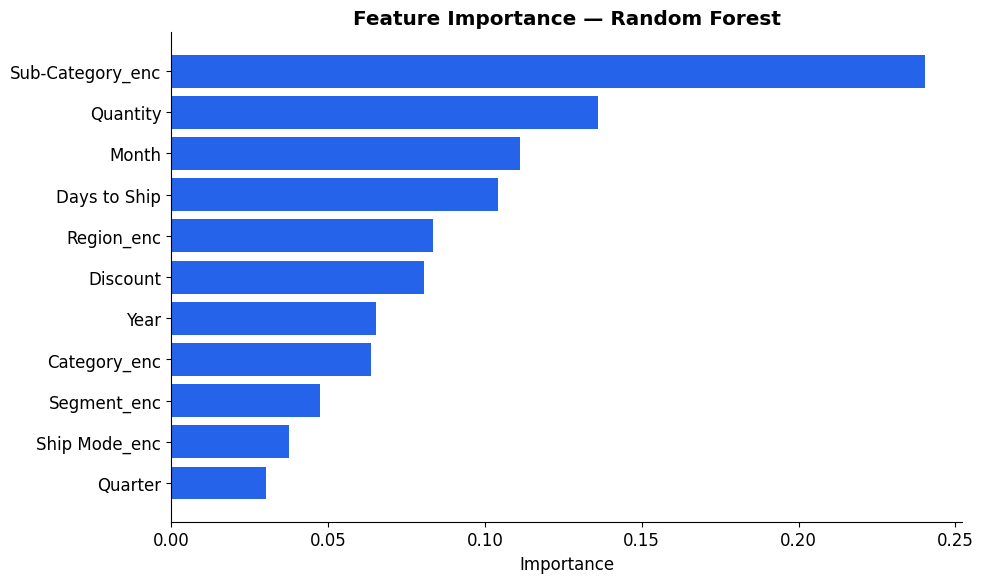

In [35]:
# Feature importance (Random Forest)
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2563eb')
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusions <a id='5'></a>

In [37]:
best_r2 = results[best_model]['R²']
best_rmse = results[best_model]['RMSE']

print('=' * 55)
print('         SUPERSTORE ANALYSIS — KEY FINDINGS')
print('=' * 55)
print(f'\n DATASET')
print(f'   Period: {df["Order Date"].min().year} – {df["Order Date"].max().year}')
print(f'   Total orders: {df["Order ID"].nunique():,}')
print(f'   Total revenue: ${df["Sales"].sum():,.0f}')
print(f'   Overall margin: {df["Profit"].sum()/df["Sales"].sum()*100:.1f}%')

print(f'\n BUSINESS INSIGHTS')
top_cat = df.groupby('Category')['Sales'].sum().idxmax()
worst_sub = df.groupby('Sub-Category')['Profit'].sum().idxmin()
best_region = df.groupby('Region')['Profit'].sum().idxmax()
print(f'   Top category by sales: {top_cat}')
print(f'   Least profitable sub-category: {worst_sub}')
print(f'   Most profitable region: {best_region}')
print(f'   High discounts (>20%) consistently destroy margin')

print(f'\n ML RESULTS')
print(f'   Best model: {best_model}')
print(f'   R² Score: {best_r2:.4f}')
print(f'   RMSE: ${best_rmse:,.0f}')
print('=' * 55)

         SUPERSTORE ANALYSIS — KEY FINDINGS

 DATASET
   Period: 2014 – 2017
   Total orders: 5,009
   Total revenue: $2,297,201
   Overall margin: 12.5%

 BUSINESS INSIGHTS
   Top category by sales: Technology
   Least profitable sub-category: Tables
   Most profitable region: West
   High discounts (>20%) consistently destroy margin

 ML RESULTS
   Best model: Gradient Boosting
   R² Score: 0.1933
   RMSE: $690
